# Tutorial 2: Cell Embedding with C2S

In this tutorial, we will demonstrate how to perform cell embedding using the Cell2Sentence (C2S) models. Cell embeddings are crucial for downstream tasks such as clustering, visualization, and classification. By converting cells into embeddings, we create a compact representation that captures the essential information from the cell sentences.

In this tutorial, you will:
1. Load an immune tissue single-cell dataset from Domínguez Conde et al. (preprocessed in tutorial notebook 0, two sample donors), and create a CSData() wrapper around it
    - Citation: Domínguez Conde, C., et al. "Cross-tissue immune cell analysis reveals tissue-specific features in humans." Science 376.6594 (2022): eabl5197.
2. Load a pretrained C2S model and create a CSModel object.
3. Embed the cells using the C2S model.
4. Visualize the cell embeddings to gain insights into the data.

We will begin by importing the necessary libraries. These include Python's built-in libraries, third-party libraries for handling numerical computations, progress tracking, and specific libraries for single-cell RNA sequencing data and C2S operations.

In [1]:
# Python built-in libraries
import os
import random
from collections import Counter

# Third-party libraries
import numpy as np
from tqdm import tqdm

# Single-cell libraries
import anndata
import scanpy as sc

# Cell2Sentence imports
import cell2sentence as cs
from cell2sentence.tasks import embed_cells

/work/PRTNR/CHUV/DIR/rgottar1/single_cell_all/users/aseres1/miniforge3/envs/hack/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)

# Load Data

Next, we will load the preprocessed dataset from the tutorial 0. This dataset has already been filtered and normalized, so it it ready for transformation into cell sentences.

<font color='red'>Please make sure you have completed the preprocessing steps in Tutorial 0 before running the following code, if you are using your own dataset.</font>. Ensure that the file path is correctly set in <font color='gold'>DATA_PATH</font> to where your preprocessed data was saved from tutorial 0.

In [3]:
DATA_PATH = "/work/PRTNR/CHUV/DIR/rgottar1/citeseq/anna/Citeseq-Hackathon/data.h5ad"

In [4]:
adata = anndata.read_h5ad(DATA_PATH)
adata

AnnData object with n_obs × n_vars = 180794 × 24719
    obs: 'sample', 'batch_ID', 'Sample', 'Run', 'Subject', 'Status', 'DemuxletDropletType', 'IncludedInStudy', 'CellType', 'Cluster', 'n_genes'
    var: 'n_cells'
    uns: 'CellType_colors', 'batch_ID_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [5]:
adata.obs["cell_type"] = adata.obs["CellType"].astype(str)
adata.obs.drop(columns =["CellType"], inplace=True)
adata.obs["organism"] = "Homo Sapiens"

In [6]:
#adata.obs = adata.obs[["CellType", "batch_ID", "Status"]]
adata.obs.drop(columns=["sample","batch_ID","Sample","Run","Subject","Status","DemuxletDropletType","IncludedInStudy","IncludedInStudy","Cluster","n_genes"],inplace=True)

In [7]:
adata.obs

,cell_type,organism
PBMC-02-1_AAACCCAGTAGCTGTT,gdT,Homo Sapiens
PBMC-02-1_AAACCCATCAGCCTTC,CD14 Mono,Homo Sapiens
PBMC-02-1_AAACCCATCGGCTGGT,CD4 TCM,Homo Sapiens
PBMC-02-1_AAACCCATCGTGGACC,CD8 TEM,Homo Sapiens
PBMC-02-1_AAACGAAAGTACAGAT,CD8 Naive,Homo Sapiens
...,...,...
PBMC-07-4_TTTGTTGGTGGACCTC,pDC,Homo Sapiens
PBMC-07-4_TTTGTTGTCAGGGTAG,CD14 Mono,Homo Sapiens
PBMC-07-4_TTTGTTGTCATACAGC,CD14 Mono,Homo Sapiens
PBMC-07-4_TTTGTTGTCCGTGTAA,CD4 CTL,Homo Sapiens


In [8]:
adata.obs.head()

,cell_type,organism
PBMC-02-1_AAACCCAGTAGCTGTT,gdT,Homo Sapiens
PBMC-02-1_AAACCCATCAGCCTTC,CD14 Mono,Homo Sapiens
PBMC-02-1_AAACCCATCGGCTGGT,CD4 TCM,Homo Sapiens
PBMC-02-1_AAACCCATCGTGGACC,CD8 TEM,Homo Sapiens
PBMC-02-1_AAACGAAAGTACAGAT,CD8 Naive,Homo Sapiens


In [9]:
adata.var.head()

,n_cells
RP11-34P13.7,400
RP11-34P13.8,19
RP11-34P13.9,19
FO538757.3,17
FO538757.2,21285


We are expecting log10 base 10 transformed data, with a maximum value somewhere around 3 or 4. Make sure to start with processed and normalized data when doing the cell sentence conversion!

# Cell2Sentence Conversion + CSData Creation

In this section, we will transform our AnnData object containing our single-cell dataset into a Cell2Sentence (C2S) dataset by calling the functions of the CSData class in the C2S code base. Full documentation for the functions of the CSData class can be found in the documentation page of C2S.

In [10]:
#adata_obs_cols_to_keep = ["CellType", "Status", "batch_ID"]
adata_obs_cols_to_keep = ["cell_type","organism"]


In [11]:
# Create CSData object
arrow_ds, vocabulary = cs.CSData.adata_to_arrow(
    adata=adata, 
    random_state=SEED, 
    sentence_delimiter=' ',
    label_col_names=adata_obs_cols_to_keep
)

100%|██████████| 180794/180794 [01:06<00:00, 2730.91it/s]


We can visualize one sample of our created arrow dataset as follows:

In [12]:
sample_idx = 0
arrow_ds[sample_idx]

{'cell_name': 'PBMC-02-1_AAACCCAGTAGCTGTT',
 'cell_sentence': 'MALAT1 B2M MT-ATP6 MT-CO1 MT-CO2 TMSB4X RPS27 MT-CO3 MT-CYB RPL10 ACTB GNLY EEF1A1 RPL28 MT-ND4 RPL41 TMSB10 RPLP1 RPL13 RPS12 HLA-B RPS28 CCL5 RPLP2 RPS29 IL32 TPT1 MT-ND3 RPS3 RPS4X HLA-A RPL34 RPL30 RPL39 RPS27A RPL3 NKG7 RPS3A RPL11 RPS15A RPL37A RPL37 RPL19 RPL32 RPS18 RPL26 RPS10 RPS6 MT-ND5 RPS2 RPL36 PTMA RPS24 RPL23A S100A4 RPL18A RPS19 RPS21 RPL27A RPS23 PFN1 HLA-C RPS26 RPL21 MT-ND1 RPL35A FAU RPL22 RPS25 RPL36A RPL38 RPL8 EIF1 HLA-E MT-ND2 RPL14 RPS16 RPL27 RPL7A RPL35 RPS8 RPL5 RPL6 RPL24 RPS9 RPS13 RPS7 SH3BGRL3 RPS15 RPL18 RPL10A RPSA RPL12 RPS14 RPL15 PLAC8 CD3E MYL12A RPL9 FTL TXNIP NACA RPL13A KLF2 RPL29 HMGB1 RPS11 CST7 DDX5 UBA52 RPLP0 CD3G TRDC CFL1 HOPX RPL23 ARPC2 UQCRB KLRB1 RPL17 PTPRC UQCR11 GNB2L1 UBC NDUFA4 GZMA SEPT7 ATP5G2 CALM1 KLRD1 TRBC1 RPL4 IFITM2 AES SOD1 PCBP1 TMEM50A CTSW RPL36AL H3F3A HINT1 CD52 PFDN5 GPX4 UBL5 CD2 HSP90B1 KLRG1 BTG1 SERP1 LSP1 BCL2 ATP5G3 REST S100A11 FXYD5 HCST PPIA 

In [13]:
c2s_save_dir = "/work/PRTNR/CHUV/DIR/rgottar1/citeseq/anna/Citeseq-Hackathon/c2s_api_testing"  # C2S dataset will be saved into this directory
c2s_save_name = "c2s_data"  # This will be the name of our C2S dataset on disk

In [14]:
csdata = cs.CSData.csdata_from_arrow(
    arrow_dataset=arrow_ds, 
    vocabulary=vocabulary,
    save_dir=c2s_save_dir,
    save_name=c2s_save_name,
    dataset_backend="arrow"
)

Saving the dataset (4/4 shards): 100%|██████████| 180794/180794 [00:01<00:00, 149029.38 examples/s]


In [15]:
print(csdata)

CSData Object; Path=/work/PRTNR/CHUV/DIR/rgottar1/citeseq/anna/Citeseq-Hackathon/c2s_api_testing/c2s_data, Format=arrow


We can retrieve the cell sentences from our dataset using the get_sentence_strings() function of our csdata object:

In [16]:
cell_sentences_list = csdata.get_sentence_strings()

In [17]:
def print_first_N_genes(cell_sentence_str: str, top_k_genes: int, delimiter: str = " "):
    """Helper function to print K genes of a cell sentence."""
    print(delimiter.join(cell_sentence_str.split(delimiter)[:top_k_genes]))

In [18]:
print_first_N_genes(cell_sentences_list[0], top_k_genes=200)

MALAT1 B2M MT-ATP6 MT-CO1 MT-CO2 TMSB4X RPS27 MT-CO3 MT-CYB RPL10 ACTB GNLY EEF1A1 RPL28 MT-ND4 RPL41 TMSB10 RPLP1 RPL13 RPS12 HLA-B RPS28 CCL5 RPLP2 RPS29 IL32 TPT1 MT-ND3 RPS3 RPS4X HLA-A RPL34 RPL30 RPL39 RPS27A RPL3 NKG7 RPS3A RPL11 RPS15A RPL37A RPL37 RPL19 RPL32 RPS18 RPL26 RPS10 RPS6 MT-ND5 RPS2 RPL36 PTMA RPS24 RPL23A S100A4 RPL18A RPS19 RPS21 RPL27A RPS23 PFN1 HLA-C RPS26 RPL21 MT-ND1 RPL35A FAU RPL22 RPS25 RPL36A RPL38 RPL8 EIF1 HLA-E MT-ND2 RPL14 RPS16 RPL27 RPL7A RPL35 RPS8 RPL5 RPL6 RPL24 RPS9 RPS13 RPS7 SH3BGRL3 RPS15 RPL18 RPL10A RPSA RPL12 RPS14 RPL15 PLAC8 CD3E MYL12A RPL9 FTL TXNIP NACA RPL13A KLF2 RPL29 HMGB1 RPS11 CST7 DDX5 UBA52 RPLP0 CD3G TRDC CFL1 HOPX RPL23 ARPC2 UQCRB KLRB1 RPL17 PTPRC UQCR11 GNB2L1 UBC NDUFA4 GZMA SEPT7 ATP5G2 CALM1 KLRD1 TRBC1 RPL4 IFITM2 AES SOD1 PCBP1 TMEM50A CTSW RPL36AL H3F3A HINT1 CD52 PFDN5 GPX4 UBL5 CD2 HSP90B1 KLRG1 BTG1 SERP1 LSP1 BCL2 ATP5G3 REST S100A11 FXYD5 HCST PPIA ST13 H3F3B CYBA PRF1 PTPN4 TCF25 ARPC1B HNRNPD TRGC1 IER2 RPS20

In [19]:
print_first_N_genes(cell_sentences_list[1], top_k_genes=200)

S100A9 LYZ S100A8 RPLP1 FTL ACTB TPT1 S100A4 TMSB10 RPL41 B2M RPS14 S100A6 RPS24 RPL34 HLA-B RPS28 RPL28 EEF1A1 RPL10 CD74 FOS RPL32 RPS12 TMSB4X RPL26 FTH1 RPL39 TYROBP RPS15A RPL30 RPL19 RPL13 SH3BGRL3 RPS8 RPS23 RPL18A RPL11 RPL37 RPS15 RPL12 RPS18 CST3 FCN1 RPS2 RPS13 RPL35A RPL29 RPS27 RPL6 GSTP1 PTMA S100A10 RPS3A MT-CO2 RPS4X PFN1 UBA52 RPS10 RPS27A RPL7A GAPDH FAU ATP5E RPL37A RPS16 RPL21 RPL36 RPS29 RPS6 SERF2 RPL18 NACA RPS3 RPS19 RPS7 RPLP2 MT-CO3 RPL15 S100A12 RPL38 H3F3A RPS21 OAZ1 AIF1 CYBA RPL27 RPL35 RPL36A RPL8 RPL22 RPL3 RPL14 COTL1 S100A11 RPL10A RPL23A PFDN5 RPL5 JUNB CTSS FCER1G SRGN RPS9 RPS25 HLA-DRA TSPO APLP2 FXYD5 ARPC1B VCAN EIF1 COX6B1 ACTG1 CFL1 TKT UQCR11 CD14 TOMM7 ATP5G2 YBX1 HLA-A HCST GNB2L1 CHCHD2 GRN STXBP2 CLIC1 IER2 RHOA MNDA RPL9 PPIA CORO1A MYL6 RHOG BTF3 CALM2 ZFP36 RPL24 LSP1 ANXA1 EDF1 PABPC1 TMA7 PPDPF CFP HLA-C PSAP RPL17 JUND AP1S2 HLA-E ARHGDIB OST4 CD52 RPS11 H3F3B DUSP1 GPX1 PRELID1 HLA-DRB1 RPL7 COX4I1 MT-ND2 SSR4 RPSA TMEM176B ATP5L RP

# Cell embedding

Now, we will embed cells using C2S. First, we need to load a pretrained C2S model which we will do cell embedding with. Any C2S model would do here for extracting embeddings, however we strongly recommend C2S models which have been trained to do cell type or tissue prediction. 

For this tutorial, we will go with the C2S-Pythia-410M cell type prediction model, which was trained to do cell type prediction on many datasets from CellxGene and Human Cell Atlas. This model will provide us with a strong LLM for obtaining cell-level embeddings, since it was trained to discriminate cell types on a diverse array of datasets and cell type annotations. More details about the C2S-Pythia-410M cell type prediction model can be found in the Model Zoo section of the ReadME in the GitHub repo, or in the Huggingface model card.

We can define our CSModel object with our pretrained cell type prediction model as follows:

In [20]:
from transformers import AutoModel

In [21]:
model = AutoModel.from_pretrained("vandijklab/C2S-Pythia-410m-cell-type-prediction")

Loading weights: 100%|██████████| 291/291 [00:00<00:00, 32379.43it/s]
GPTNeoXModel LOAD REPORT from: vandijklab/C2S-Pythia-410m-cell-type-prediction
Key              | Status     |  | 
-----------------+------------+--+-
embed_out.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [22]:
# Define CSModel object
cell_type_prediction_model_path = ""
save_dir = "/work/PRTNR/CHUV/DIR/rgottar1/citeseq/anna/Citeseq-Hackathon/model_save"
save_name = "hackathon_c2s"
csmodel = cs.CSModel(
    model_name_or_path="vandijklab/C2S-Pythia-410m-cell-type-prediction",
    save_dir=save_dir,
    save_name=save_name
)

Using device: cuda


Writing model shards: 100%|██████████| 1/1 [00:09<00:00,  9.95s/it]


In [23]:
print(csmodel)

CSModel Object; Path=/work/PRTNR/CHUV/DIR/rgottar1/citeseq/anna/Citeseq-Hackathon/model_save/hackathon_c2s


In [24]:
print(csdata)
adata.shape[0]

CSData Object; Path=/work/PRTNR/CHUV/DIR/rgottar1/citeseq/anna/Citeseq-Hackathon/c2s_api_testing/c2s_data, Format=arrow


180794

We will use the embed_cells() function from tasks.py to obtain cell embeddings using our C2S model. The function takes as input a CSData and CSModel objects, as well as the number of genes to use per cell sentence. It will:
1. Load the C2S model and data
2. Format the cell sentences into prompts for cell type prediction
3. Run the prompts through the C2S model
4. Collect and return cell embeddings

In [25]:
from cell2sentence.prompt_formatter import C2SPromptFormatter
prompt_formatter = C2SPromptFormatter(task="cell_type_prediction", top_k_genes=5)

print(prompt_formatter.prompts_dict)

{'model_input': ['The following is a list of {num_genes} gene names ordered by descending expression level in a {organism} cell. Your task is to give the cell type which this cell belongs to based on its gene expression.\nCell sentence: {cell_sentence}.\nThe cell type corresponding to these genes is:', 'Below is a list of {num_genes} gene names in order of descending expression level from a {organism} cell. Based on this, predict what the cell type of this cell is.\nCell sentence: {cell_sentence}.\nThese genes are most likely associated with cell type:', 'Given the list of {num_genes} gene names ordered by descending expression level from a {organism} cell, identify the cell type.\nCell sentence: {cell_sentence}.\nThe probable cell type for these genes is:', 'Analyze the following list of {num_genes} genes sorted by decreasing expression levels in a {organism} cell and determine its cell type.\nCell sentence: {cell_sentence}.\nBased on these genes, the corresponding cell type is:', 'Fr

In [26]:
adata

AnnData object with n_obs × n_vars = 180794 × 24719
    obs: 'cell_type', 'organism'
    var: 'n_cells'
    uns: 'CellType_colors', 'batch_ID_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [27]:
# Embed cells
embedded_cells = embed_cells(
    csdata=csdata,
    csmodel=csmodel,
    n_genes=200,
)

Reloading model from path on disk: /work/PRTNR/CHUV/DIR/rgottar1/citeseq/anna/Citeseq-Hackathon/model_save/hackathon_c2s


Loading weights: 100%|██████████| 292/292 [00:00<00:00, 29560.88it/s]


Embedding 180794 cells using CSModel...


100%|██████████| 180794/180794 [1:56:05<00:00, 25.95it/s]


In [28]:
embedded_cells.shape

(180794, 1024)

Now, we create a UMAP of the cell embeddings to visualize the embeddings obtained from the C2S model. We will add the cell embeddings to our adata object, and rerun the neighbors and UMAP algorithms in Scanpy using the cell embeddings.

In [29]:
del adata.uns
del adata.obsm
del adata.varm
del adata.obsp

In [30]:
adata

AnnData object with n_obs × n_vars = 180794 × 24719
    obs: 'cell_type', 'organism'
    var: 'n_cells'

In [31]:
adata.obsm["c2s_cell_embeddings"] = embedded_cells

In [32]:
adata

AnnData object with n_obs × n_vars = 180794 × 24719
    obs: 'cell_type', 'organism'
    var: 'n_cells'
    obsm: 'c2s_cell_embeddings'

In [33]:
sc.pp.neighbors(adata, use_rep="c2s_cell_embeddings")  # calculate neighbors using cell embeddings

In [34]:
sc.tl.umap(adata)

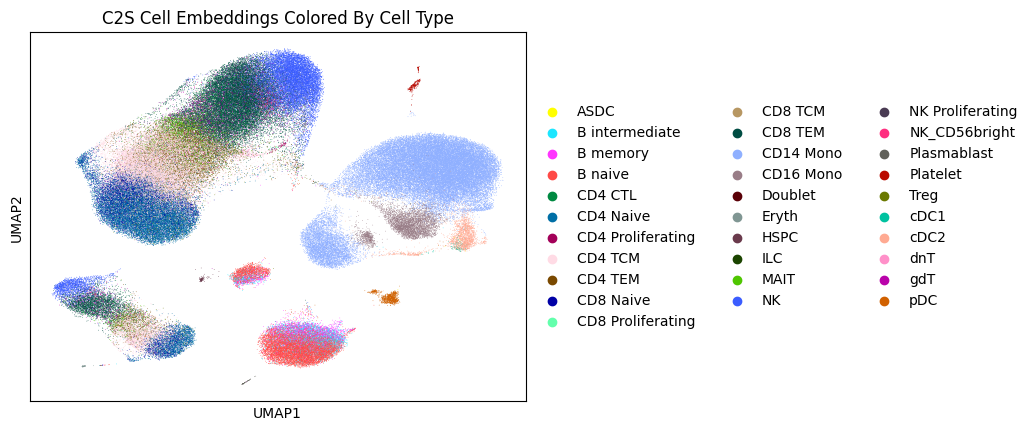

In [44]:
sc.pl.umap(
    adata,
    color="cell_type",
    size=1,
    title="C2S Cell Embeddings Colored By Cell Type",
)

In [38]:
adata.obsm["X_C2S"] = adata.obsm["c2s_cell_embeddings"]
del adata.obsm["c2s_cell_embeddings"]

In [39]:
adata

AnnData object with n_obs × n_vars = 180794 × 24719
    obs: 'cell_type', 'organism'
    var: 'n_cells'
    uns: 'neighbors', 'umap', 'cell_type_colors'
    obsm: 'X_umap', 'X_C2S'
    obsp: 'distances', 'connectivities'

In [42]:
anndata.settings.allow_write_nullable_strings = True
adata.write_h5ad('C2S_results.h5ad') 

In [43]:
import os
os.getcwd()

'/work/PRTNR/CHUV/DIR/rgottar1/citeseq/anna'

In [36]:
# sc.pl.umap(
#     adata,
#     color="batch_ID",
#     size=8,
#     title="C2S Cell Embeddings Colored By batch_ID",
# )

In [37]:
# sc.pl.umap(
#     adata,
#     color="Status",
#     size=8,
#     title="C2S Cell Embeddings Colored By Status",
# )

We can see from the UMAPs that our cell embeddings obtained from the C2S model accurately reflect the structure of the data, and retain distinct clusters separated by cell type and tissue. This is a promising sign for the embedding capability of our C2S model on single-cell datasets!